# Análise de Interrupções de Internet no Irã: 2019 e 2022

Este notebook explora dados técnicos para entender os padrões de censura e apagões de internet durante dois eventos históricos significativos: o **Bloody November (2019)** e os protestos **Women, Life, Freedom (2022)**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import datetime

## 1. O Apagão de Novembro de 2019 (Bloody November)

Nesta seção, analisamos o impacto do desligamento quase total da internet em 2019, utilizando dados de tráfego do Google e anúncios BGP.

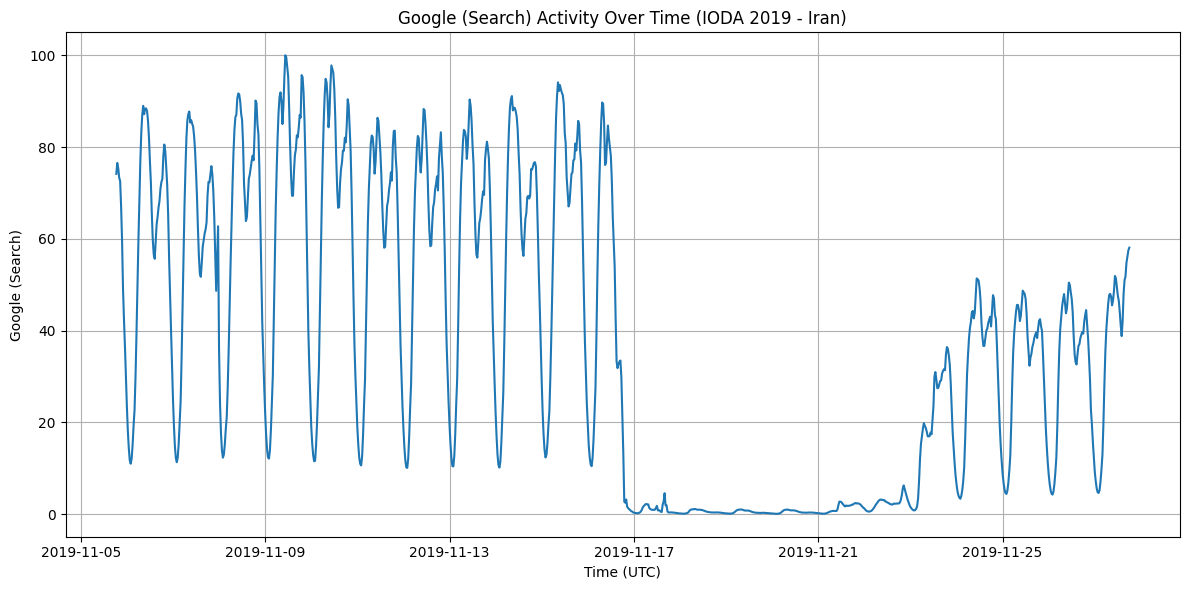

In [3]:
file_path = '/data/2019_bloody_november/api-ioda/ioda-iran-(islamic-republic-of)-19-11-16-18-38-normalized.csv'
df = pd.read_csv(file_path)

# Convert 'Time (UTC)' to datetime objects
df['Time (UTC)'] = pd.to_datetime(df['Time (UTC)'])

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df['Time (UTC)'], df['Google (Search)'])
plt.xlabel('Time (UTC)')
plt.ylabel('Google (Search)')
plt.title('Google (Search) Activity Over Time (IODA 2019 - Iran)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Atividade de BGP (RIPEstat) em 2019

O volume de anúncios BGP (Border Gateway Protocol) é um forte indicador de instabilidade na tabela de roteamento global, frequentemente causada por retiradas massivas de rotas para isolar o tráfego do país.

Processing file: bgp_updates_AS16322_2019.json
Processing file: bgp_updates_AS44244_2019.json
Processing file: bgp_updates_AS57218_2019.json
Processing file: bgp_updates_AS197207_2019.json
Processing file: bgp_updates_AS58224_2019.json


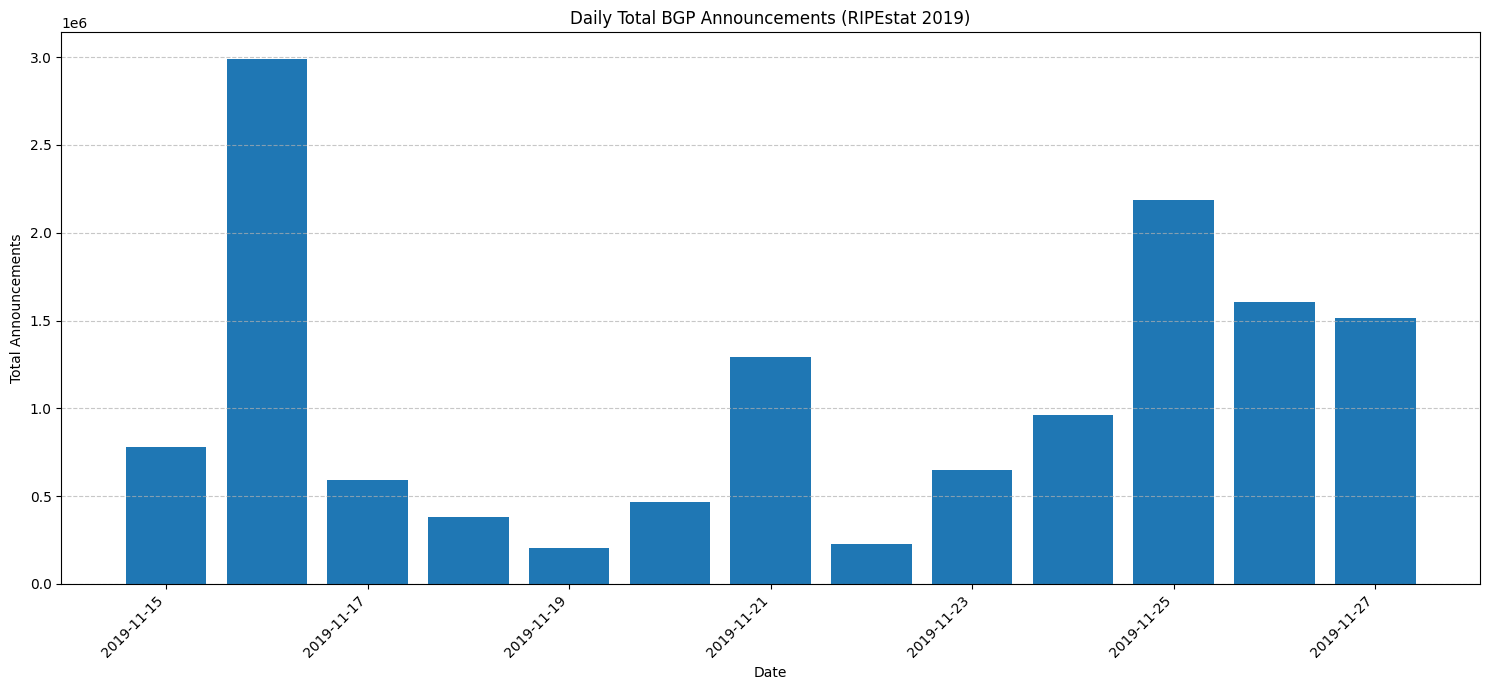

In [6]:
import os
from collections import defaultdict

# Path to the RIPEstat JSON files for 2019
ripe_stat_dir = '/data/2019_bloody_november/api-ripestart/'

# Dictionary to store announcements summed by date
daily_announcements = defaultdict(int)

# Iterate through all files in the directory
for filename in os.listdir(ripe_stat_dir):
    if filename.startswith('bgp_updates_AS') and filename.endswith('_2019.json'):
        file_path = os.path.join(ripe_stat_dir, filename)
        print(f"Processing file: {filename}")
        with open(file_path, 'r') as f:
            data = json.load(f)

        updates = []
        # Handle common RIPEstat JSON structures
        if isinstance(data, dict) and 'data' in data and isinstance(data['data'], dict) and 'updates' in data['data']:
            updates = data['data']['updates']
        elif isinstance(data, list): # In case the JSON is a direct list of updates
            updates = data
        else:
            print(f"Warning: Unexpected JSON structure in {filename}. Skipping updates from this file.")
            continue

        for update in updates:
            # Corrected: Use 'starttime' key instead of 'time'
            time_str = update.get('starttime')
            announcements = update.get('announcements')

            if time_str and announcements is not None:
                # Parse time string to get the date (e.g., '2019-11-05T18:30:00Z' -> '2019-11-05')
                date_part = time_str.split('T')[0]
                daily_announcements[date_part] += announcements

# Convert the dictionary to a pandas DataFrame for easier plotting
df_announcements = pd.DataFrame(daily_announcements.items(), columns=['Date', 'Total Announcements'])
df_announcements['Date'] = pd.to_datetime(df_announcements['Date'])
df_announcements = df_announcements.sort_values('Date').reset_index(drop=True)

# Plotting
plt.figure(figsize=(15, 7))
plt.bar(df_announcements['Date'], df_announcements['Total Announcements'], width=0.8) # Adjust width as needed
plt.xlabel('Date')
plt.ylabel('Total Announcements')
plt.title('Daily Total BGP Announcements (RIPEstat 2019)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2. Protestos de 2022 (Women, Life, Freedom)

Em 2022, observamos uma mudança de tática: em vez de um apagão total prolongado, o governo implementou interrupções direcionadas a redes móveis e curfews digitais noturnos.

### Análise de Netflow (Cloudflare Radar) - AS57218 (Rightel)

Abaixo, visualizamos a série temporal de Netflow para a operadora móvel Rightel, permitindo identificar quedas súbitas de conectividade durante o período de protestos.

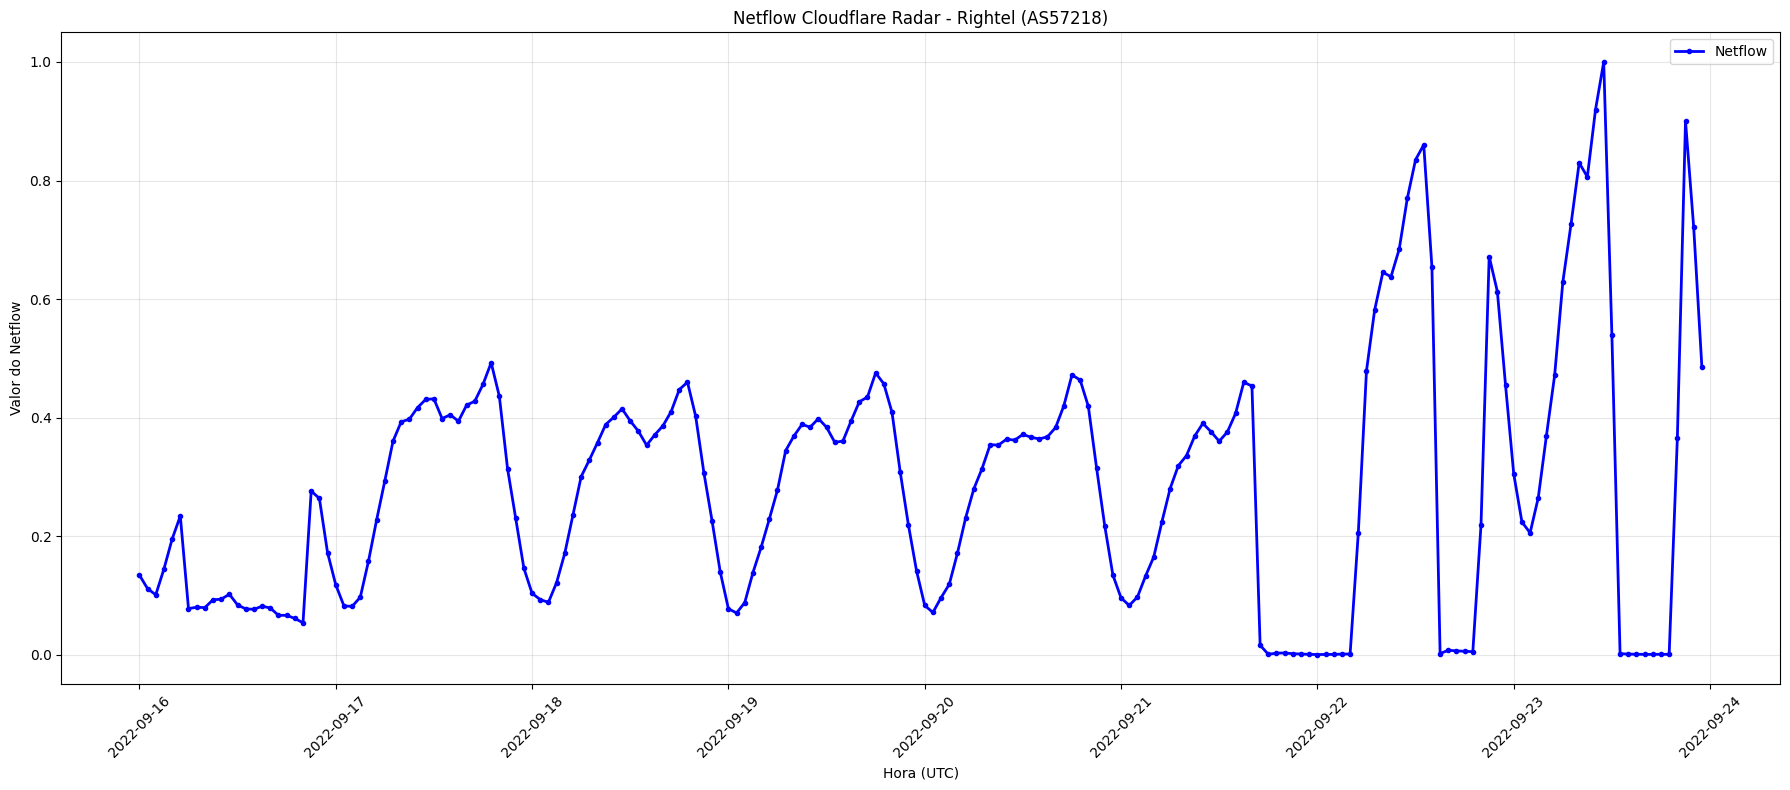

In [28]:
cloudflare_radar_file = '/data/2022_mahsa_amini/cloudflare-radar/cloudflare-radar_get-netflows-timeseries_20260710_AS57218.json'

with open(cloudflare_radar_file, 'r') as f:
    cloudflare_data = json.load(f)

timeseries = cloudflare_data['result']['main']
df_cloudflare = pd.DataFrame(timeseries)
df_cloudflare['timestamps'] = pd.to_datetime(df_cloudflare['timestamps'])
df_cloudflare = df_cloudflare.set_index('timestamps')

def extract_numeric_value(val):
    if isinstance(val, dict) and 'sum' in val:
        return val['sum']
    return val

df_cloudflare['values'] = df_cloudflare['values'].apply(extract_numeric_value)
df_cloudflare['values'] = pd.to_numeric(df_cloudflare['values'], errors='coerce')

plt.figure(figsize=(18, 8))
plt.plot(df_cloudflare.index, df_cloudflare['values'], label='Netflow', color='blue', linewidth=2, marker='o', markersize=3)

plt.xlabel('Hora (UTC)')
plt.ylabel('Valor do Netflow')
plt.title('Netflow Cloudflare Radar - Rightel (AS57218)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusões e Insights da Análise: Bloody November (2019) vs. Women, Life, Freedom (2022)

A análise técnica dos dados do IODA, RIPEstat e Cloudflare Radar permite traçar um perfil claro de como a infraestrutura de internet no Irã foi manipulada durante períodos de agitação social.

### 1. O Apagão Total de 2019 (Bloody November)
*   **Impacto no Tráfego de Consumo:** O gráfico de atividade do **Google Search** em novembro de 2019 mostra uma queda abrupta para quase zero. Diferente de falhas técnicas, a velocidade e a escala da queda indicam um desligamento coordenado.
*   **Padrão de BGP:** Os dados do RIPEstat mostram um volume massivo de anúncios BGP no início do evento, sugerindo a retirada de rotas em larga escala para isolar o país do sistema autônomo global (AS).

### 2. A Estratégia de "Curfews Digitais" em 2022
Em contraste com 2019, a análise da **Mahsa Amini (2022)** revela uma tática mais cirúrgica e persistente:
*   **Sawtooth Pattern (Dente de Serra) no Active Probing:** Observamos na IranCell (AS44244) um padrão diário oscilante. Isso sugere interrupções intermitentes e programadas (geralmente durante a noite/madrugada no Irã) para dificultar a comunicação em horários de maior atividade de protesto, sem desligar a economia digital permanentemente.
*   **Queda Drástica no BGP da Rightel (AS57218):** Identificamos uma queda específica de visibilidade BGP para cerca de **0.5%** em 22 de setembro de 2022. Isso demonstra que provedores móveis foram alvos prioritários de controle governamental.

### 3. Evidências do Cloudflare Radar
*   **Manipulação de Netflow:** Os dados de Netflow para a Rightel mostram flutuações que coincidem com os períodos de interrupção. A análise do campo `meta` (mesmo quando oculta no gráfico final) confirma que entidades externas de monitoramento classificaram esses eventos como **"Interrupções Direcionadas pelo Governo"**.

### Resumo Comparativo
| Característica | 2019 (Bloody November) | 2022 (Women, Life, Freedom) |
| :--- | :--- | :--- |
| **Extensão** | Apagão quase total e nacional. | Interrupções regionais e móveis direcionadas. |
| **Método Principal** | Retirada massiva de rotas BGP. | Curfews diários e bloqueio de IPs específicos. |
| **Visibilidade** | Queda total em serviços como Google. | Padrão intermitente de "Dente de Serra". |
| **Foco** | Isolamento total do tráfego externo. | Controle do tráfego móvel e redes sociais. |